# TAREA 1 : Introducción al análisis y procesamiento de audio con Python.
## Asignatura: Sistemas multimedia.
## Alumno/a: Sandra Maldonado Marín.
## Sesión 3

###1. Importar librerías y módulos de Python

In [ ]:
from scipy.io import wavfile
import IPython
import os
import numpy as np

###2. Especificar directorios de entrada y salida

In [ ]:
# Directorios que usaremos.
cwd = os.getcwd()
audio_input_path = os.path.join(cwd, os.path.join('sample_data')) # Para audios de entrada
audio_output_path = os.path.join(cwd, os.path.join('sample_data')) # Para audios de salida
print(f'Directorio con los audios de entrada: {audio_input_path}')
print(f'Directorio donde guardaremos los audios generados: {audio_output_path}\n')

Directorio con los audios de entrada: /content/sample_data
Directorio donde guardaremos los audios generados: /content/sample_data



###3. Cargar el archivo del audio que se desee

In [ ]:
# Cargamos el archivo de audio.
filename = os.path.join(audio_input_path, 'the_last_of_us_reduced.wav')
sample_rate, audio_data = wavfile.read(filename)
# Frecuencia de muestreo:
print(f'Frecuencia de muestreo (sample rate): {sample_rate/1000} kHz')
# Número de canales:
numeroCanales = audio_data.shape[1] if audio_data.ndim > 1 else 1
print(f'Número de canales de audio: {numeroCanales}')
# Tamaño del archivo:
tamaño_bytes = os.path.getsize(filename) # Calcularlo en bytes
tamaño_mb = tamaño_bytes / (1024 * 1024) # Calcularlo en Mb
print(f'Tamaño del archivo: {tamaño_mb:.2f} Mb')

Frecuencia de muestreo (sample rate): 44.1 kHz
Número de canales de audio: 2
Tamaño del archivo: 0.84 Mb


###4. Incluir widget para reproducir audio estéreo

In [ ]:
IPython.display.Audio(audio_data.T, rate=sample_rate) # .T se pasa únicamente si es audio estéreo.

###5. Convertir el audio estéreo a mono

In [ ]:
# Convertimos a mono mediante la media por canal (simplificacion).
audio_mono = audio_data.mean(axis=1)  # Column-wise. --> Si fuera axis=0, el numpy sería de tamaño (1, 2) ||| Con axis=1 l numpy es de tamaño 2171299, 1)
# Mostramos las mismas características que con el estéreo, y así vemos el cambio:
# Frecuencia de muestreo:
print(f'Frecuencia de muestreo (sample rate): {sample_rate/1000} kHz')
# Número de canales:
numeroCanales = audio_mono.shape[1] if audio_mono.ndim > 1 else 1
print(f'Número de canales de audio: {numeroCanales}')
# Tamaño del archivo:
tamaño_bytes = os.path.getsize(filename)
tamaño_mb = tamaño_bytes / (1024 * 1024)
print(f'Tamaño del archivo: {tamaño_mb:.2f} Mb')

Frecuencia de muestreo (sample rate): 44.1 kHz
Número de canales de audio: 1
Tamaño del archivo: 0.84 Mb


Vemos que la única diferencia entre el audio estéreo a mono, es que en el audio mono, solo hay un canal de audio, lógicamente. El resto de datos son exactamente iguales.

###6. Guardar el archivo mono a un fichero .wav

In [ ]:
wavfile.write( # Para crear cualquier archivo .wav
    filename=os.path.join(audio_output_path, 'audio_mono.wav'),
    rate=sample_rate,
    data=audio_mono
)

###7. Incluir widget para reproducir audio mono

In [ ]:
IPython.display.Audio(audio_mono, rate=sample_rate)

###8. Podemos ver la diferencia en el peso de los dos archivos .wav

In [ ]:
!ls -sh /content/sample_data/the_last_of_us_reduced.wav # Tamaño del audio estéreo
!ls -sh /content/sample_data/audio_mono.wav # Tamaño del audio mono

864K /content/sample_data/the_last_of_us_reduced.wav
1.7M /content/sample_data/audio_mono.wav


El audio mono, al tener un solo canal de audio, va a tener mucho mas peso (el docle) que el estéreo, el cual tiene el doble de canales, que en este caso es 2.

###9. Gráfica con el dominio del audio estéreo, frente al mono

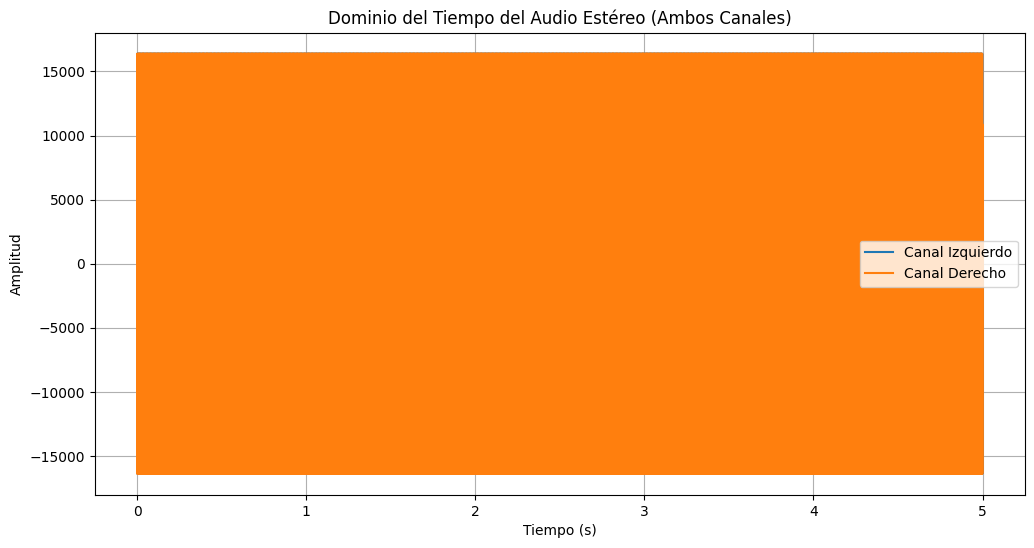

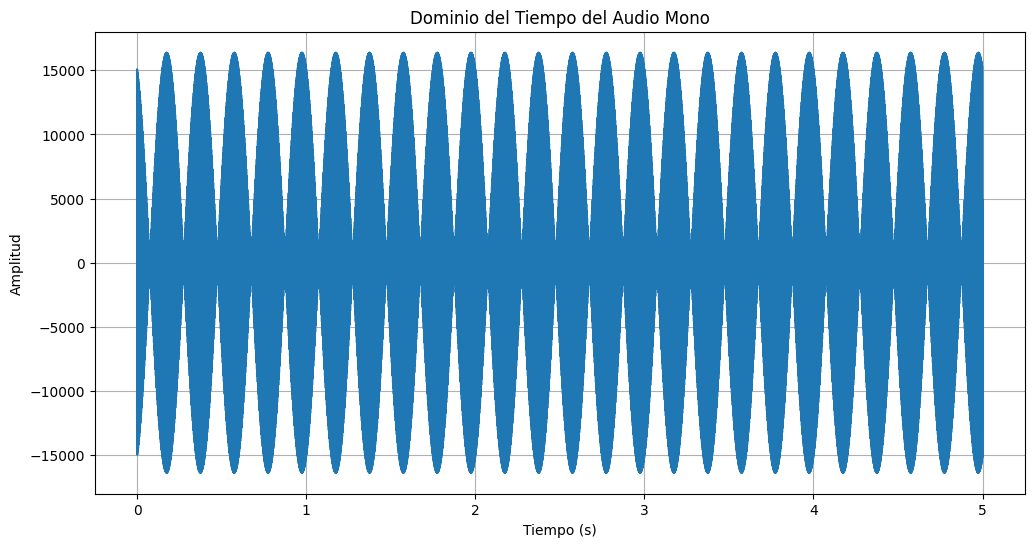

In [ ]:
import matplotlib.pyplot as plt #Librerías necesarias
import numpy as np

def plot_audio_time_domain(audio_data, sample_rate, title, channel=None):
    plt.figure(figsize=(12, 6)) # Crear una figura

    time = np.linspace(0, len(audio_data) / sample_rate, num=len(audio_data)) # Un array para representar el tiempo en la gráfica

    if audio_data.ndim > 1: # Stereo or multi-channel
        if channel is None:
            # Plot both channels
            plt.plot(time, audio_data[:, 0], label='Canal Izquierdo')
            plt.plot(time, audio_data[:, 1], label='Canal Derecho')
            plt.legend()
        elif channel == 0:
            plt.plot(time, audio_data[:, 0], label='Canal Izquierdo')
        elif channel == 1:
            plt.plot(time, audio_data[:, 1], label='Canal Derecho')
        else:
            print(f"Advertencia: Canal {channel} no válido. Mostrando Canal Izquierdo por defecto.")
            plt.plot(time, audio_data[:, 0], label='Canal Izquierdo')

    else: # Mono-channel
        plt.plot(time, audio_data)

    plt.title(title)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid()
    plt.show()

# Plotting the time domain for the original stereo audio (both channels)
plot_audio_time_domain(audio_data, sample_rate, 'Dominio del Tiempo del Audio Estéreo (Ambos Canales)', channel=None)


# Plotting the time domain for the mono audio
plot_audio_time_domain(audio_mono, sample_rate, 'Dominio del Tiempo del Audio Mono')

###10. Concluciones

Tras hacer todas estas pruebas, observamos que la diferencia entre un audio estéreo y mono, es que, el estéreo utiliza al menos dos canales de audio (el izquierdo y derecho), que esto se puede apreciar si se escucha el audio con auriculares en los dos oidos, y el audio mono, tiene un solo canal, se unifican todas las ondas en uno solo, entonces en el oido izquierdo captaremos el mismo sonido que en el derecho.

Se puede destacar, que el estéreo es la forma más similar en la que los humanos percibimos los sonidos, ya que se divide en dos canales mínimo, para cada uno de los oidos. En cambio el mono, no.

# TAREA 2: Procesamiento de audio con Python

La gráfica del dominio del tiempo de los dos tipos de audios, ya está hecho en la tarea anterior.

###1. Explicar con tus palabras: frecuencia de muestreo, aliasing, profundidad de bits, ancho de banda y tasa de bits.
- Frecuencia de muestreo: la frecuencia es el número de muestras que se toman en cada segundo del sonido. De esta forma obtenemos datos para poder saber lo máximo posible de estas ondas.
- Aliasing: es el solapamiento, y ocurre cuando varias señales distintas son solapadas entre ellas, ya que la frecuencia de muestreo es muy baja, es decir, tenemos muy pocos datos sobre las ondas.
- Profundidad de bits: mide la cantidad de bits que se pueden almacenar para medir la onda sonora y las muestras, es decir, después de obtener la onda que se desee del sonido que sea, hay que almacenarlo en algún sitio.
- Ancho de banda: es la suma de la profuncidad de bits, más la frecuencia de muestreo, es decir, que con el ancho de banda obtenemos la precisión de la señal que hemos obtenido, a diferencia de la original.
- Tasa de bits: esta se centra simplemente en el tamaño del archivo del audio digital, el generado por nosotros, no del audio original. Se basa en la cantidad de bits que hay que procesar por segundo para producir el audio digital.

###



###2. Audio mono. Aplicar la Transformada rápida de Fourier (FFT) para cambiar al dominio de la frecuencia. Mostrar la gráfica y explicar el por qué.

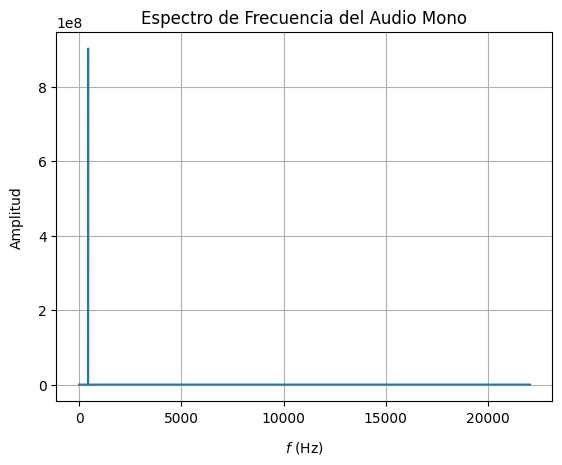

In [ ]:
import matplotlib.pyplot as plt # Importamos la librería para graficar

# La longitud del array de datos y el
# sample rate (frecuencia de muestreo).
n = len(audio_mono) # Usamos audio_mono en lugar de audio_data_48
Fs = sample_rate # Usamos sample_rate en lugar de sample_rate_48

# Calculando la Transformada Rapida de Fourier (FFT) en audio mono.
ch_Fourier = np.fft.fft(audio_mono)  # ch1 # Aplicamos FFT a audio_mono

# Solo miramos frecuencia por debajo de Fs/2
# (Nyquist-Shannon) --> Spectrum.
abs_ch_Fourier = np.absolute(ch_Fourier[:n//2])

# Graficamos.
plt.plot(np.linspace(0, Fs/2, n//2), abs_ch_Fourier)
plt.ylabel('Amplitud', labelpad=10)
plt.xlabel('$f$ (Hz)', labelpad=10)
plt.title('Espectro de Frecuencia del Audio Mono')
plt.grid(True)
plt.show()

Vemos en la gráfica un pico muy alto hacia arriba porque el audio analizado tiene una frecuencia dominante, y este representa la frecuencia con mayor amplitud de todo el audio. Solo se ve ese pico, porque todo el sonido estará concentrado alrededor de esa frecuencia.

###3. Calcular la energía del espectrograma y la frecuencia de corte eligiendo un epsilon (probad diferentes pero comentad solo uno).